# 05 · Factor model for the five-view lidar redundancy

**Data character.** Within one inventory cycle the five `*_omdrev1` stand variables — biomass, basal area, volume, mean height, mean diameter — pair-correlate at $\rho > 0.9$. They are five lidar-derived projections of the same underlying stand state.

**Modelling claim.** A single latent $z_n$ per pixel explains most of that joint variation. Each observed view is then a linear readout of $z_n$ plus view-specific noise. That is a one-factor model.

$$ z_n \sim \mathcal{N}(0, 1) \qquad y_{n,k} \mid z_n \sim \mathcal{N}(\mu_k + \lambda_k z_n,\; \sigma_k^2) $$

Why bother:
1. Replaces 5 collinear regressors with 1 informative latent → cleaner downstream regression on $\Delta\text{volym}$.
2. Quantifies *how much* extra information the 2nd, 3rd, ... view carries (posterior on $\lambda_k$ and $\sigma_k$).
3. Generative — we can prior-predictive simulate forests and check the correlation pattern matches what we see.

Identifiability: $z \to -z,\; \lambda \to -\lambda$ leaves the likelihood unchanged, and $z \to cz,\; \lambda \to \lambda/c,\; \sigma\to\sigma$ does too. Fix scale by $z \sim \mathcal{N}(0,1)$ and fix sign by pinning $\lambda_0 = +1$ (biomass) below.

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive, MCMC, NUTS
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

pyro.set_rng_seed(42)
torch.set_default_dtype(torch.float32)
PROJECT_DIR = Path.cwd()

/Users/mondrup/Library/Mobile Documents/com~apple~CloudDocs/DTU/Model-based machine learning 42186/Projects/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Load data and confirm the redundancy

Re-use the existing preprocessing pipeline (filter to stable forest, drop *_omdrev2 leakage). Then pull out only the five views.

In [2]:
from notebook_helpers import load_dataset, apply_filter_and_features

VIEW_COLS = [
    'biomassa_omdrev1',     # biomass
    'grundyta_omdrev1',     # basal area
    'volym_omdrev1',        # volume
    'medelhojd_omdrev1',    # mean canopy height
    'medeldiameter_omdrev1' # mean stem diameter
]
VIEW_LABELS = ['bio', 'BA', 'vol', 'CH', 'diam']

df_raw = load_dataset(PROJECT_DIR / 'out_5km_idx_preprocessed.csv')
df = apply_filter_and_features(df_raw)
Y_all = df[VIEW_COLS].to_numpy(np.float32)
print(f'Y_all: {Y_all.shape},  any NaN? {np.isnan(Y_all).any()}')

Rows before mask: 160,000
Rows after  mask: 63,073
BK cells with ≥1 surviving pixel: 121
  median pixels per BK: 551
  min/max pixels per BK: 18 / 1070
Y_all: (63073, 5),  any NaN? False


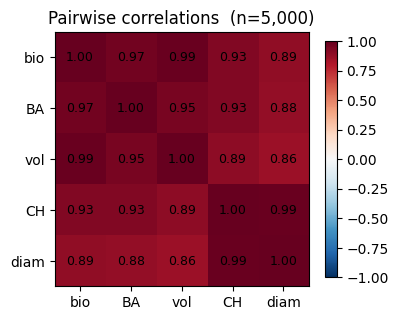

In [3]:
# Subsample for development — full 100k+ rows is fine for SVI but slow for NUTS.
rng = np.random.default_rng(0)
N_DEV = 5000
idx = rng.choice(len(Y_all), size=min(N_DEV, len(Y_all)), replace=False)
Y = Y_all[idx]

# Per-view standardisation. The model has its own mu_k, but standardising
# stabilises optimisation and lets us read lambda_k as 'fraction of view
# variance explained by z'.
Y_mu, Y_sd = Y.mean(0), Y.std(0)
Y_std = (Y - Y_mu) / Y_sd

corr = np.corrcoef(Y_std.T)
fig, ax = plt.subplots(figsize=(4, 3.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(5)); ax.set_xticklabels(VIEW_LABELS)
ax.set_yticks(range(5)); ax.set_yticklabels(VIEW_LABELS)
for i in range(5):
    for j in range(5):
        ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title(f'Pairwise correlations  (n={len(Y):,})')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()

## 2 · PGM

Latent $z_n$ in white, the five observed views in grey, loadings $\lambda$ and noises $\sigma$ outside the plate. The PyPI package is `daft-pgm` (it still imports as `daft`).

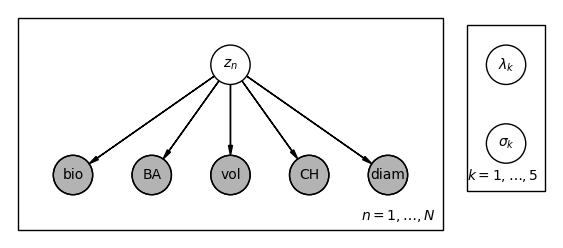

In [4]:
import daft

pgm = daft.PGM()
# Latent + observed views (all inside the n-plate below).
pgm.add_node('z', r'$z_n$', 0.0, 2.4)
for i, lab in enumerate(VIEW_LABELS):
    pgm.add_node(lab, lab, -2.0 + i * 1.0, 1.0, observed=True)
    pgm.add_edge('z', lab)
# Per-view parameters live OUTSIDE the n-plate, INSIDE their own k-plate.
pgm.add_node('lam', r'$\lambda_k$', 3.5, 2.4)
pgm.add_node('sig', r'$\sigma_k$', 3.5, 1.4)
# n-plate: encloses z and the five views.
pgm.add_plate([-2.7, 0.3, 5.4, 2.7], label=r'$n = 1,\ldots,N$', position='bottom right')
# k-plate: encloses just lambda_k and sigma_k.
pgm.add_plate([3.0, 0.8, 1.0, 2.1], label=r'$k = 1,\ldots,5$', position='bottom right')
pgm.render(); plt.show()

## 3 · The Pyro model

Two plates: rows $n$ and views $k$. The likelihood is treated as `to_event(1)` over the 5 views so each pixel contributes a single 5-dim observation.

In [5]:
K = 5

def factor_model(Y_obs=None, N=None):
    if Y_obs is not None:
        N = Y_obs.shape[0]
    # Loadings: pin lambda_0 = +1 to fix sign+scale of z.
    lam_free = pyro.sample('lam_free',
                           dist.Normal(torch.zeros(K - 1), 1.0).to_event(1))
    # Shape-agnostic cat — Predictive(guide=AutoNormal) can introduce a
    # leading particle dim, so we can't assume lam_free is 1-D here.
    ones = torch.ones_like(lam_free[..., :1])
    lam = torch.cat([ones, lam_free], dim=-1)
    mu = pyro.sample('mu', dist.Normal(torch.zeros(K), 1.0).to_event(1))
    sigma = pyro.sample('sigma', dist.HalfNormal(torch.ones(K)).to_event(1))
    with pyro.plate('rows', N):
        z = pyro.sample('z', dist.Normal(0., 1.))             # (N,)
        loc = mu + lam * z.unsqueeze(-1)                       # (N, K)
        pyro.sample('y', dist.Normal(loc, sigma).to_event(1),
                    obs=Y_obs)

## 4 · Prior predictive check

Before fitting: sample fake datasets from the prior and look at their correlation matrix. If the prior can't produce $\rho \approx 0.9$ structure, our priors are too tight. If it produces $\rho$ all over the place, our priors are too loose but at least the data we observe is reachable.

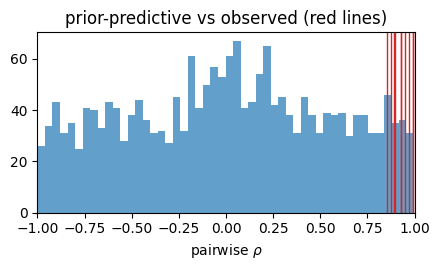

In [6]:
prior_pred = Predictive(factor_model, num_samples=200)(Y_obs=None, N=500)
Y_sim = prior_pred['y'].numpy()  # (200, 500, 5)

# Distribution of off-diagonal pairwise correlations across simulated datasets
rhos = []
for s in range(Y_sim.shape[0]):
    c = np.corrcoef(Y_sim[s].T)
    rhos.extend(c[np.triu_indices(K, k=1)])
fig, ax = plt.subplots(figsize=(4.5, 2.8))
ax.hist(rhos, bins=50, alpha=0.7, label='prior-predictive')
obs_rhos = corr[np.triu_indices(K, k=1)]
for r in obs_rhos:
    ax.axvline(r, color='C3', lw=1)
ax.set_xlabel(r'pairwise $\rho$'); ax.set_xlim(-1, 1)
ax.set_title('prior-predictive vs observed (red lines)')
plt.tight_layout(); plt.show()

## 5 · Variational inference (SVI)

`AutoNormal` is a mean-field gaussian guide — fast, captures point estimates and marginal uncertainty, doesn't capture posterior correlations between $\lambda$ components. Good enough for a first pass; revisit with `AutoMultivariateNormal` or NUTS for accurate correlations.

step     0  ELBO loss = 44,806
step   200  ELBO loss = 17,740
step   400  ELBO loss = 13,137
step   600  ELBO loss = 11,696
step   800  ELBO loss = 11,054
step  1000  ELBO loss = 10,767
step  1200  ELBO loss = 10,426
step  1400  ELBO loss = 10,314
step  1600  ELBO loss = 10,230
step  1800  ELBO loss = 10,174


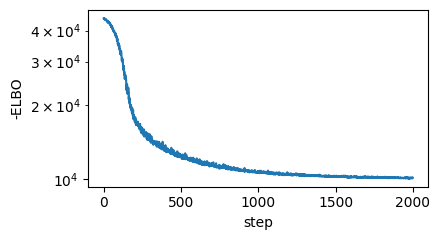

In [7]:
Y_t = torch.tensor(Y_std)
pyro.clear_param_store()
guide = AutoNormal(factor_model)
svi = SVI(factor_model, guide, Adam({'lr': 5e-3}), loss=Trace_ELBO())

losses = []
for step in range(2000):
    loss = svi.step(Y_obs=Y_t)
    losses.append(loss)
    if step % 200 == 0:
        print(f'step {step:>5d}  ELBO loss = {loss:,.0f}')

fig, ax = plt.subplots(figsize=(4.5, 2.5))
ax.plot(losses); ax.set_xlabel('step'); ax.set_ylabel('-ELBO')
ax.set_yscale('log'); plt.tight_layout(); plt.show()

In [8]:
# Posterior samples via the guide.
# Predictive(guide=AutoNormal) returns tensors of shape (S, 1, *event); the
# helper below squeezes that extra particle dim when present.
post = Predictive(factor_model, guide=guide, num_samples=400,
                  return_sites=['lam_free', 'mu', 'sigma', 'z'])(Y_obs=Y_t)

def _drop_particle(t):
    if t.dim() > 2 and t.shape[1] == 1:
        t = t.squeeze(1)
    return t

lam_free_post = _drop_particle(post['lam_free'])
sig_post      = _drop_particle(post['sigma']).numpy()
z_post        = _drop_particle(post['z']).numpy()
lam_post      = torch.cat(
    [torch.ones(lam_free_post.shape[0], 1), lam_free_post], dim=1
).numpy()

summary = pd.DataFrame({
    'view':        VIEW_LABELS,
    'lambda_mean': lam_post.mean(0),
    'lambda_sd':   lam_post.std(0),
    'sigma_mean':  sig_post.mean(0),
    'frac_var_z':  lam_post.mean(0)**2 / (lam_post.mean(0)**2 + sig_post.mean(0)**2),
})
summary

,view,lambda_mean,lambda_sd,sigma_mean,frac_var_z
0,bio,1.000000,0.000000,0.060152,0.996395
1,BA,0.973055,0.009078,0.251915,0.937186
2,vol,0.995685,0.005439,0.130256,0.983174
3,CH,0.928510,0.012896,0.376709,0.858662
4,diam,0.884522,0.015373,0.463777,0.784365


**Reading the table.** `frac_var_z` $= \lambda_k^2 / (\lambda_k^2 + \sigma_k^2)$ is the share of each standardised view explained by the latent. If it's $\approx$ 0.9+ for all five, one factor really is enough; if one view drops to 0.5 it has its own private structure and deserves its own latent.

## 6 · Sanity check: recovered $z_n$ vs simple average

If the factor model just rediscovers "the average of the five standardised views", that's actually the right answer for a one-factor problem and confirms identification worked.

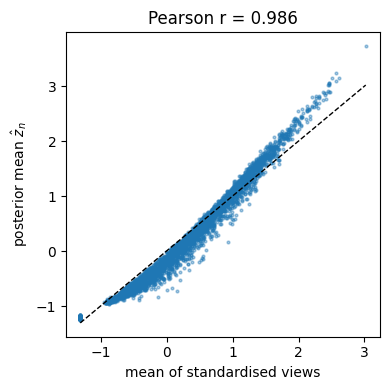

In [9]:
z_mean = z_post.mean(0)
z_naive = Y_std.mean(axis=1)

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(z_naive, z_mean, s=4, alpha=0.4)
lo, hi = z_naive.min(), z_naive.max()
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlabel(r'mean of standardised views'); ax.set_ylabel(r'posterior mean $\hat z_n$')
ax.set_title(f'Pearson r = {np.corrcoef(z_naive, z_mean)[0,1]:.3f}')
plt.tight_layout(); plt.show()

## 7 · MCMC (NUTS) on a small subset for comparison

NUTS on the full N is slow because $z_n$ is sampled per pixel. Subsample further and compare $\lambda, \sigma$ to the SVI posterior — disagreement is a warning that mean-field is too restrictive.

In [10]:
N_MCMC = 500
Y_mcmc = torch.tensor(Y_std[:N_MCMC])

kernel = NUTS(factor_model, jit_compile=False)
mcmc = MCMC(kernel, num_samples=400, warmup_steps=400, num_chains=1)
mcmc.run(Y_obs=Y_mcmc)
mcmc.summary()

Sample: 100%|██████████| 800/800 [00:33, 23.62it/s, step size=4.33e-02, acc. prob=0.913]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
lam_free[0]      0.96      0.01      0.96      0.94      0.98     83.76      1.00
lam_free[1]      0.99      0.01      0.99      0.98      1.00    226.73      1.00
lam_free[2]      0.93      0.02      0.93      0.90      0.95     62.07      1.00
lam_free[3]      0.89      0.02      0.89      0.86      0.92    112.21      1.00
      mu[0]      0.05      0.01      0.05      0.04      0.06      7.51      1.09
      mu[1]      0.05      0.01      0.05      0.03      0.08     31.66      1.04
      mu[2]      0.05      0.01      0.05      0.03      0.06     18.09      1.04
      mu[3]      0.04      0.02      0.04      0.01      0.06     59.91      1.01
      mu[4]      0.04      0.02      0.04      0.01      0.07    101.72      1.00
   sigma[0]      0.01      0.00      0.01      0.01      0.01     20.37      1.00
   sigma[1]      0.25      0.01      0.25      0.24      0.27    126.42      1.00
   sigma[2]    

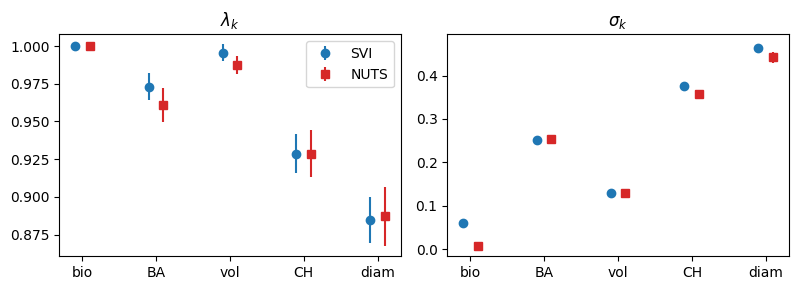

In [11]:
nuts = mcmc.get_samples()
lam_nuts = torch.cat([torch.ones(nuts['lam_free'].shape[0], 1),
                      nuts['lam_free']], dim=1).numpy()
sig_nuts = nuts['sigma'].numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for k in range(K):
    axes[0].errorbar(k - 0.1, lam_post[:, k].mean(), yerr=lam_post[:, k].std(),
                     fmt='o', color='C0', label='SVI' if k == 0 else None)
    axes[0].errorbar(k + 0.1, lam_nuts[:, k].mean(), yerr=lam_nuts[:, k].std(),
                     fmt='s', color='C3', label='NUTS' if k == 0 else None)
    axes[1].errorbar(k - 0.1, sig_post[:, k].mean(), yerr=sig_post[:, k].std(),
                     fmt='o', color='C0', label='SVI' if k == 0 else None)
    axes[1].errorbar(k + 0.1, sig_nuts[:, k].mean(), yerr=sig_nuts[:, k].std(),
                     fmt='s', color='C3', label='NUTS' if k == 0 else None)
axes[0].set_xticks(range(K)); axes[0].set_xticklabels(VIEW_LABELS)
axes[1].set_xticks(range(K)); axes[1].set_xticklabels(VIEW_LABELS)
axes[0].set_title(r'$\lambda_k$'); axes[1].set_title(r'$\sigma_k$')
axes[0].legend(); plt.tight_layout(); plt.show()

## 8 · Two-factor extension

### Why a second latent

The one-factor fit was great for the mass cluster (bio, BA, vol — all `frac_var_z` > 0.93) but visibly weaker for the geometry pair (CH 0.86, **diam 0.78**). That ~20 % private variance is structure a single shared scalar literally cannot reach.

The heatmap in §1 told us where it lives: CH and diam pair-correlate at $\rho = 0.99$ with each other but only $\rho = 0.86\text{–}0.93$ with the mass trio. Two latents — one for "stand mass," one for "stand geometry" — should close the gap.

### The model

$$
\mathbf{z}_n \in \mathbb{R}^2 \;\sim\; \mathcal{N}(\mathbf{0}, I_2) \qquad
y_{n,k} \mid \mathbf{z}_n \;\sim\; \mathcal{N}\!\Big(\mu_k + \sum_{j=1}^{2} \Lambda_{k,j}\, z_{n,j},\; \sigma_k^2\Big)
$$

Each view is now a linear readout of *two* latents via a $5\times 2$ loading matrix $\Lambda$. The marginal covariance of $\mathbf{y}_n$ becomes $\Lambda\Lambda^\top + \mathrm{diag}(\sigma^2)$ — a low-rank-plus-diagonal decomposition of the 5×5 view covariance. (This is exactly probabilistic PCA / factor analysis.)

### Identifiability — the gotcha

Two factors brings *three* ways the parameters can compensate without changing the likelihood:

1. **Scale.** $\Lambda \mathbf{z} = (c\Lambda)(c^{-1}\mathbf{z})$. Killed by $\mathbf{z} \sim \mathcal{N}(0, I)$.
2. **Sign.** Flip the sign of column $j$ of $\Lambda$ AND of $z_{\cdot,j}$ — unchanged. Per column.
3. **Rotation.** For any orthogonal $R$, $\Lambda \mathbf{z} = (\Lambda R)(R^\top \mathbf{z})$, and $R^\top \mathbf{z}$ is still $\mathcal{N}(0, I)$. The two latent axes can spin freely around each other.

If you don't constrain these, SVI will land somewhere arbitrary, NUTS will mix poorly, and the loading matrix you read off will be unreadable. The fix is the **Anderson–Rubin / Geweke–Zhou constraint**: force $\Lambda$ to be **lower triangular with positive diagonal** in its first $J$ rows.

For $J=2$ this means

$$
\Lambda \;=\; \begin{bmatrix}
1 & 0 \\
\Lambda_{1,0} & \Lambda_{1,1}^{+} \\
\Lambda_{2,0} & \Lambda_{2,1} \\
\Lambda_{3,0} & \Lambda_{3,1} \\
\Lambda_{4,0} & \Lambda_{4,1}
\end{bmatrix}
$$

where $\Lambda_{0,0} = 1$ (pinned, kills scale of factor 0), $\Lambda_{0,1} = 0$ (kills rotation), and $\Lambda_{1,1}^{+} \sim \text{HalfNormal}$ (positive, kills factor-1's sign). Three numbers locked down, and everything else is free.

### View ordering matters now

Because rows 0 and 1 are the *anchors*, the views you place there **define what the two factors mean.** We re-order so that:

| row | view | role |
|---|---|---|
| 0 | `bio` (biomass)        | anchor → factor 0 ≈ "mass axis"      |
| 1 | `CH` (mean height)     | anchor → factor 1 ≈ "geometry residual" |
| 2 | `BA` (basal area)      | free both columns |
| 3 | `vol` (volume)         | free both columns |
| 4 | `diam` (mean diameter) | free both columns |

**Prediction** (if the two-cluster story is correct): after fitting, `BA` and `vol` should load heavily on factor 0 and near-zero on factor 1; `diam` should load on both with comparable magnitude. We'll check this against the loading table below.


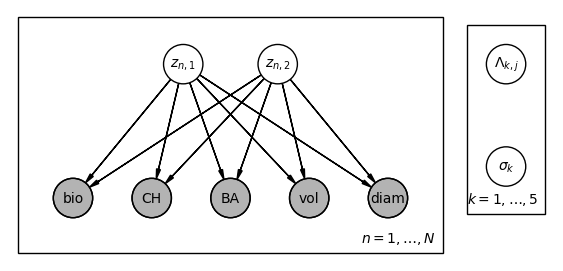

In [12]:
# Two-factor PGM
import daft

pgm = daft.PGM()
# Two latents stacked vertically inside the n-plate.
pgm.add_node('z1', r'$z_{n,1}$', -0.6, 2.7)
pgm.add_node('z2', r'$z_{n,2}$',  0.6, 2.7)
# Five observed views.
labs_2f = ['bio', 'CH', 'BA', 'vol', 'diam']
for i, lab in enumerate(labs_2f):
    pgm.add_node(lab, lab, -2.0 + i * 1.0, 1.0, observed=True)
    pgm.add_edge('z1', lab)
    pgm.add_edge('z2', lab)
# Loading matrix and per-view noise outside the n-plate, inside a k-plate.
pgm.add_node('lam', r'$\Lambda_{k,j}$', 3.5, 2.7)
pgm.add_node('sig', r'$\sigma_k$', 3.5, 1.4)
pgm.add_plate([-2.7, 0.3, 5.4, 3.0], label=r'$n = 1,\ldots,N$', position='bottom right')
pgm.add_plate([ 3.0, 0.8, 1.0, 2.4], label=r'$k = 1,\ldots,5$', position='bottom right')
pgm.render(); plt.show()


### Building the model in Pyro

The trick in code is to **assemble $\Lambda$ from a few sampled scalars** rather than sampling the whole matrix at once. That way the lower-triangular constraint is enforced by construction — we never sample the zero entry, and `HalfNormal` keeps $\Lambda_{1,1}$ positive — instead of needing a clever guide.

Three sites: `lam_10` (a free scalar), `lam_11` (a positive scalar via `HalfNormal`), and `lam_rest` (a 3×2 block, fully free). Stack them with row 0 = `[1, 0]` and you have $\Lambda$.

The `(z.unsqueeze(-2) * Lam.unsqueeze(-3)).sum(-1)` is a shape-agnostic way to compute $\mathbf{z}\Lambda^\top$ for each pixel; it tolerates the leading particle dim that `Predictive(guide=AutoNormal)` likes to add (we hit this issue in §3).


In [13]:
J = 2  # number of latent factors

# Reorder columns so that row 0 = bio (mass anchor), row 1 = CH (geometry anchor)
VIEW_COLS_2F   = ['biomassa_omdrev1', 'medelhojd_omdrev1',
                  'grundyta_omdrev1', 'volym_omdrev1', 'medeldiameter_omdrev1']
VIEW_LABELS_2F = ['bio', 'CH', 'BA', 'vol', 'diam']

Y_2f_all = df[VIEW_COLS_2F].to_numpy(np.float32)
Y_2f     = Y_2f_all[idx]                                 # same 5,000-pixel subsample
Y_2f_std = (Y_2f - Y_2f.mean(0)) / Y_2f.std(0)
Y_2f_t   = torch.tensor(Y_2f_std)

def factor_model_2(Y_obs=None, N=None):
    if Y_obs is not None:
        N = Y_obs.shape[0]
    K_, J_ = 5, 2

    # Anchors and free entries
    lam_10   = pyro.sample('lam_10',   dist.Normal(0., 1.))                   # CH on factor 0
    lam_11   = pyro.sample('lam_11',   dist.HalfNormal(1.))                   # CH on factor 1 (positive)
    lam_rest = pyro.sample('lam_rest', dist.Normal(torch.zeros(K_-2, J_), 1.).to_event(2))

    # Assemble Lambda (..., K, J) — shape-safe under a leading particle dim
    ones  = torch.ones_like(lam_10).unsqueeze(-1)
    zeros = torch.zeros_like(lam_10).unsqueeze(-1)
    row0  = torch.cat([ones,  zeros], dim=-1)            # [1, 0]
    row1  = torch.stack([lam_10, lam_11], dim=-1)        # [lam_10, lam_11+]
    Lam   = torch.cat([row0.unsqueeze(-2),
                       row1.unsqueeze(-2),
                       lam_rest], dim=-2)                # (..., K=5, J=2)

    mu    = pyro.sample('mu',    dist.Normal(torch.zeros(K_), 1.).to_event(1))
    sigma = pyro.sample('sigma', dist.HalfNormal(torch.ones(K_)).to_event(1))

    with pyro.plate('rows', N):
        z   = pyro.sample('z', dist.Normal(torch.zeros(J_), 1.).to_event(1))  # (N, J)
        # loc[n, k] = mu_k + sum_j z[n, j] * Lam[k, j]
        loc = mu + (z.unsqueeze(-2) * Lam.unsqueeze(-3)).sum(-1)              # (N, K)
        pyro.sample('y', dist.Normal(loc, sigma).to_event(1), obs=Y_obs)


step     0  ELBO loss = 54,473
step   250  ELBO loss = 20,616
step   500  ELBO loss = 10,917
step   750  ELBO loss = 6,958
step  1000  ELBO loss = 5,225
step  1250  ELBO loss = 4,519
step  1500  ELBO loss = 4,181
step  1750  ELBO loss = 3,870
step  2000  ELBO loss = 3,810
step  2250  ELBO loss = 3,636


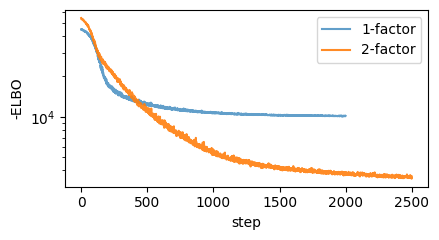

In [14]:
# Fit with SVI (same recipe as the 1-factor model)
pyro.clear_param_store()
guide_2 = AutoNormal(factor_model_2)
svi_2   = SVI(factor_model_2, guide_2, Adam({'lr': 5e-3}), loss=Trace_ELBO())

losses_2 = []
for step in range(2500):
    loss = svi_2.step(Y_obs=Y_2f_t)
    losses_2.append(loss)
    if step % 250 == 0:
        print(f'step {step:>5d}  ELBO loss = {loss:,.0f}')

fig, ax = plt.subplots(figsize=(4.5, 2.5))
ax.plot(losses,   label='1-factor', alpha=0.7)
ax.plot(losses_2, label='2-factor', alpha=0.9)
ax.set_xlabel('step'); ax.set_ylabel('-ELBO'); ax.set_yscale('log')
ax.legend(); plt.tight_layout(); plt.show()


In [15]:
# Posterior samples and assemble the full loading matrix Lambda
post_2 = Predictive(factor_model_2, guide=guide_2, num_samples=400,
                    return_sites=['lam_10','lam_11','lam_rest','mu','sigma','z'])(Y_obs=Y_2f_t)

def _sq(t):
    """Strip a singleton particle dim AutoNormal inserts at position 1.
    Safe no-op when the dim isn't 1 (e.g. for the z site)."""
    return t.squeeze(1) if t.dim() >= 2 else t

lam10   = _sq(post_2['lam_10']).numpy()    # (S,)
lam11   = _sq(post_2['lam_11']).numpy()    # (S,)
lamrest = _sq(post_2['lam_rest']).numpy()  # (S, 3, 2)
sigma2  = _sq(post_2['sigma']).numpy()     # (S, 5)
z2      = _sq(post_2['z']).numpy()         # (S, N, 2)

S = lam10.shape[0]
Lam_post = np.zeros((S, 5, 2), dtype=np.float32)
Lam_post[:, 0, 0] = 1.0
Lam_post[:, 0, 1] = 0.0
Lam_post[:, 1, 0] = lam10
Lam_post[:, 1, 1] = lam11
Lam_post[:, 2:, :] = lamrest

Lam_mean = Lam_post.mean(0)
Lam_sd   = Lam_post.std(0)
sig_mean = sigma2.mean(0)

loading = pd.DataFrame({
    'view':        VIEW_LABELS_2F,
    'lam_mass':    Lam_mean[:, 0].round(3),
    'lam_mass_sd': Lam_sd[:,   0].round(3),
    'lam_geom':    Lam_mean[:, 1].round(3),
    'lam_geom_sd': Lam_sd[:,   1].round(3),
    'sigma':       sig_mean.round(3),
    'frac_var':    ((Lam_mean[:,0]**2 + Lam_mean[:,1]**2) /
                    (Lam_mean[:,0]**2 + Lam_mean[:,1]**2 + sig_mean**2)).round(3),
})
loading

,view,lam_mass,lam_mass_sd,lam_geom,lam_geom_sd,sigma,frac_var
0,bio,1.000,0.000,0.000,0.000,0.041,0.998
1,CH,0.832,0.003,0.384,0.003,0.081,0.992
2,BA,0.955,0.007,0.059,0.007,0.247,0.938
3,vol,1.010,0.003,-0.073,0.004,0.104,0.990
4,diam,0.775,0.004,0.467,0.004,0.110,0.986


### Reading the loading matrix

A few things to look for as a group:

1. **`lam_geom` for `bio` is zero by construction** — that's the anchor we set. So `bio` is *defined* to lie purely on the mass axis. Don't read anything into that zero.
2. **`lam_geom` for `CH` is the (positive-by-construction) anchor for the geometry factor.** Its magnitude tells you how strong the geometry direction needs to be to explain CH on top of mass.
3. **The real test is the four un-anchored entries**: `BA`, `vol` loadings on factor 1, and `diam` loadings on both. If the two-cluster story is correct we'd see:
    - `BA`, `vol`:  large `lam_mass`, small `|lam_geom|`
    - `diam`:       moderate `lam_mass`, large `lam_geom` (similar in magnitude to CH's)
4. **`sigma` (per-view residual noise) should drop across the board vs the 1-factor fit** — adding a factor steals variance from σ. If a particular σ doesn't drop, that view's private structure isn't aligned with the second factor and a third factor (or a different parameterisation) might help.
5. **`frac_var` is now the share of view variance explained by the *2-d* latent space** ($\Lambda_{k,0}^2 + \Lambda_{k,1}^2$ over total). It should be ≥ the 1-factor `frac_var_z` for every view; the gain on `CH` and `diam` is the headline.

If any of these checks fail (e.g. `lam_geom` for `BA` is large), the factor labels we chose aren't the natural axes the data wants, and we'd need to relabel — but the *fit quality* still holds because the model is invariant to which view we anchor.


1-factor : mean |residual rho| off-diag = 0.028   max |residual| = 0.169
2-factor : mean |residual rho| off-diag = 0.020   max |residual| = 0.049


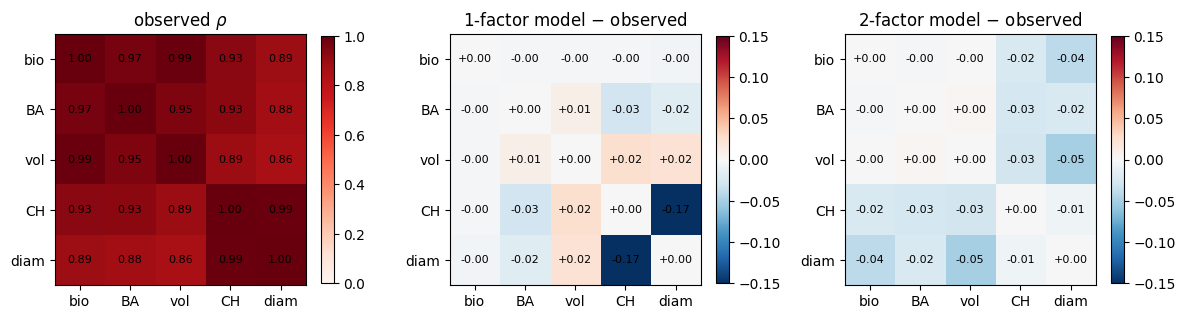

In [16]:
# The deciding test: compare the model-implied correlation matrix to the
# observed one. For this model, Cov(y) = Lambda Lambda^T + diag(sigma^2)
# in closed form, so we don't need to resample y at all — that's both
# faster and avoids the guide-N-mismatch from re-running Predictive.

def implied_corr(Lam, sigma):
    """Lam: (S, K, J), sigma: (S, K).  Returns (K, K) posterior-mean corr."""
    Cov = (np.einsum('skj,slj->skl', Lam, Lam)
           + sigma[:, :, None]**2 * np.eye(Lam.shape[1])[None, :, :])
    diag = np.diagonal(Cov, axis1=-2, axis2=-1)              # (S, K)
    norm = np.sqrt(diag[:, :, None] * diag[:, None, :])      # (S, K, K)
    return (Cov / norm).mean(0)

# --- 1-factor implied corr (Lambda has J=1, so promote lam_post to (S, K, 1)) ---
C_1 = implied_corr(lam_post[..., None], sig_post)

# --- 2-factor implied corr, reordered into VIEW_LABELS order ---
reorder = [VIEW_LABELS_2F.index(v) for v in VIEW_LABELS]
C_2 = implied_corr(Lam_post[:, reorder, :], sigma2[:, reorder])

C_obs = corr                # observed rho matrix from §1
R_1   = C_1 - C_obs
R_2   = C_2 - C_obs

iu = np.triu_indices(5, k=1)
print(f'1-factor : mean |residual rho| off-diag = {np.abs(R_1[iu]).mean():.3f}'
      f'   max |residual| = {np.abs(R_1[iu]).max():.3f}')
print(f'2-factor : mean |residual rho| off-diag = {np.abs(R_2[iu]).mean():.3f}'
      f'   max |residual| = {np.abs(R_2[iu]).max():.3f}')

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
panels = [('observed $\\rho$',                C_obs, 0.0,  1.0,  'Reds'),
          ('1-factor model $-$ observed',     R_1,  -0.15, 0.15, 'RdBu_r'),
          ('2-factor model $-$ observed',     R_2,  -0.15, 0.15, 'RdBu_r')]
for ax, (t, M, vmin, vmax, cmap) in zip(axes, panels):
    im = ax.imshow(M, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(5)); ax.set_xticklabels(VIEW_LABELS)
    ax.set_yticks(range(5)); ax.set_yticklabels(VIEW_LABELS)
    fmt_str = '{:+.2f}' if '$-$' in t else '{:.2f}'
    for i in range(5):
        for j in range(5):
            ax.text(j, i, fmt_str.format(M[i,j]),
                    ha='center', va='center', fontsize=8)
    ax.set_title(t)
    plt.colorbar(im, ax=ax, shrink=0.75)
plt.tight_layout(); plt.show()

### Reading the deciding plot

The middle and right panels are **model-implied $\rho$ minus observed $\rho$**. Off-diagonal residuals near zero mean the model reproduces the actual correlation pattern; large positive or negative residuals mean it can't.

Specifically, what we expect to see if our two-cluster theory is right:

- **1-factor panel**: a *positive* CH–diam residual (because $\rho_{\text{CH,diam}} = 0.99$ in the data but the model, with one shared scalar and CH/diam loadings of ~0.93/0.88, can't push their correlation above $\approx 0.93 \times 0.88 = 0.82$) — and *negative* cross-cluster residuals (the model over-correlates bio with CH/diam).
- **2-factor panel**: those residuals should shrink toward zero. The bottom-row "mean |residual ρ|" number is the one-line summary; it should drop by a factor of several.

If we see that pattern, we have an *interpretable* result: each factor describes one biophysically distinct axis of stand variation (mass vs geometry), and adding the second factor measurably improves how well the model fits the joint structure — not just the marginals. That's a much stronger claim than "the loss went down."

### What to flag in the report

- Two latents are sufficient (no third factor needed) **if** the residual panel for the 2-factor model has all off-diagonals within ~0.02.
- The mass-vs-geometry decomposition is **not arbitrary**: it falls out of the data once you stop forcing one scalar to explain five views. The PGM and the loading table together justify why $z \in \mathbb{R}^2$, not $z \in \mathbb{R}$ or $z \in \mathbb{R}^3$, is the right modelling choice for this dataset.
- Downstream: the recovered $(\hat{z}_{n,1}, \hat{z}_{n,2})$ is a much cleaner pair of regressors than the five raw lidar columns for predicting $\Delta\text{volym}$ — both because it's 2-d instead of 5-d, and because the two axes are *interpretable*.


## 9 · Next steps

Once this one-factor fit looks credible:

1. **Posterior predictive check on $\rho$** — re-sample $Y$ from posterior, compare its 5×5 correlation matrix to the observed one. If a residual off-diagonal block survives (e.g. biomass-volume still correlate after conditioning on $z$), one factor isn't enough.
2. **Promote $z_n$ to a feature.** Drop the five raw views from the downstream $\Delta\text{volym}$ regression and use $\hat z_n$ (posterior mean) plus its uncertainty. Check whether NLPD / CRPS on the BK-blocked test set improves.
3. **Add the composition latent.** Species-mix variables (`*_gran_volym`, `*_tall_volym`, `*_bjork_volym`) can be folded into a second latent or kept observed — the residuals of $y$ given $z$ should tell you which.
4. **Add the spatial layer.** ICAR over BK cells or a low-rank GP over (x, y) on the residuals after $z$ and composition. This is the layer that should explain the Moran's I you're already reporting in the comparison notebook.